# Electrical stimulation fMRI: stitching and preprocessing

1. Convert the raw Bruker functional scans (same session and subject, acquired back-to-back with identical acquisition parameters) to NIfTI and concatenate them in the given order. The first volumes of every scan are dropped before stitching, because the signal of a new scan is not yet in steady state (a bright first volume that decays over a few volumes). Optionally, the stitched series is then corrected for susceptibility distortion with a reverse phase-encoded EPI (FSL topup, one field estimated from the first volume of the series).
2. Motion-correct the stitched series once against a single reference volume (the middle volume of the whole series).
3. Draw the brain mask on the middle volume, compute the mean motion-corrected image and process the structural scan.

Distortion correction is selected in the pipeline steps at the top (untick *Distortion Correction* to skip it). If it is selected, enter the scan number of the reverse phase-encoded EPI. The phase-encoding axis and blip sign are detected from the Bruker metadata (the sign is only a best guess, so the detected values are shown and need to be confirmed before topup runs) or can be set manually. The corrected data is stored in its own `stitched_<scans>_<sequence>_distcorr` folder, so corrected and uncorrected runs never overwrite each other and the mask is drawn on the corrected images.

Optionally (step *Normalise Scan Levels*, off by default), the scans are scaled so that the signal level continues across the stitching points, which removes steps between scans caused by e.g. a change of the head position relative to the coil. One factor per scan is applied (`scan_normalization.csv`), so changes within a scan stay untouched. Real differences between scans, e.g. a lasting change after the stimulation, are removed as well, so keep the baseline of an analysis in the same scan as its signal window when this is used. The settings are part of the folder name (`..._distcorr_drop10_norm`), so runs with different settings never overwrite each other.

Enter the functional scan numbers in acquisition order. `scan_boundaries.csv` in the functional analysis folder records the volume range of each original scan.

Every step is skipped when its output already exists and is newer than its inputs, so the notebook can simply be run again. Tick *Force re-run* to recompute everything. The results go to the stitched folder (`func.nii.gz`, `mc_func.nii.gz`, masks) and to `<analysis folder name>` inside it (`mean_mc_func.nii.gz`, `session.json`). `session.json` is loaded by `mol_fMRI_electric_stim_analysis.ipynb`, which continues from here.

In [1]:
import importlib
import electric_stim_helpers, electric_stim_session
import mol_fMRI_distortion_correction_rp as distortion_correction
importlib.reload(electric_stim_helpers)  # picks up edits of the helper modules without restarting the kernel
importlib.reload(electric_stim_session)
importlib.reload(distortion_correction)
from electric_stim_helpers import *
from electric_stim_session import *

In [2]:
def int_widget(value, desc):
    return widgets.IntText(value=value, description=desc, layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})


def print_selected_pipeline_steps():
    print("\nPIPELINE STEP SELECTION SUMMARY")
    print("-" * 40)
    for step in PIPELINE_STEPS:
        print(f"[{'✓' if checkboxes[step['key']].value else ' '}] {step['name']}")
    print("-" * 40)


def is_step_enabled(step_key):
    return checkboxes.get(step_key, None) and checkboxes[step_key].value


PIPELINE_STEPS = [
    {"name": "Bruker → NIfTI + Stitching", "key": "bruker_to_nifti"},
    {"name": "Distortion Correction", "key": "distortion_correction"},
    {"name": "Motion Correction", "key": "motion_correction"},
    {"name": "Masking", "key": "masking_file"},
    {"name": "Normalise Scan Levels", "key": "scan_normalization", "default": False}]

checkboxes = {step["key"]: widgets.Checkbox(value=step.get("default", True), description=step["name"], indent=False) for step in PIPELINE_STEPS}

display(widgets.Box(list(checkboxes.values()), layout=widgets.Layout(display="flex", flex_flow="row wrap", align_items="flex-start", gap="10px")))

Box(children=(Checkbox(value=True, description='Bruker → NIfTI + Stitching', indent=False), Checkbox(value=Tru…

In [3]:
## Make sure what functions are selected to run in the pipeline
print_selected_pipeline_steps()

# Linux workstation mounts the data under /home, macOS under /Volumes
FMRI_ROOT = next(p for p in ("/home/pschmidt/fmri_analysis", "/Volumes/pschmidt/fmri_analysis") if os.path.isdir(p))

## Choosing the raw data that needs to be analysed
root_location = f"{FMRI_ROOT}/RawData"
selected_folder = FileChooser(root_location, layout=widgets.Layout(width='1080px'))
selected_folder.show_only_dirs = True
display(selected_folder)


PIPELINE STEP SELECTION SUMMARY
----------------------------------------
[✓] Bruker → NIfTI + Stitching
[ ] Distortion Correction
[✓] Motion Correction
[✓] Masking
----------------------------------------


FileChooser(path='/Volumes/pschmidt/fmri_analysis/RawData', filename='', title='', show_hidden=False, select_d…

In [4]:
in_path = Path(selected_folder.selected_path)
print(f"Our Raw Data is located in the path {in_path}")
subject_id = extract_subject_id(in_path)

# ---------- Common styles ----------
INPUT_LAYOUT = widgets.Layout(width="280px", flex="0 0 auto")
ROW_LAYOUT = widgets.Layout(width="100%", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e")
DESC_WIDTH = "220px"

# ---------- Widgets (KEEP REFERENCES) ----------
func_scan_numbers_entered = widgets.Text(value="", placeholder="e.g. 10, 11, 12", description="Functional Scans (in order):", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
struct_scan_number_entered = int_widget(10, "Structural Scan:")
mask_source_dir_entered = widgets.Text(value="", placeholder="optional", description="Reuse masks from folder:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})

drop_vols_entered = int_widget(10, "Volumes to drop per scan:")

row = widgets.HBox([func_scan_numbers_entered, struct_scan_number_entered, drop_vols_entered], layout=ROW_LAYOUT)
analysis_name_entered = widgets.Text(value="analysis", description="Analysis folder name:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
force_rerun_entered = widgets.Checkbox(value=False, description="Force re-run of finished steps", indent=False)
row_masks = widgets.HBox([mask_source_dir_entered, analysis_name_entered, force_rerun_entered], layout=ROW_LAYOUT)

# Only used if the Distortion Correction step is selected
rev_pe_scan_number_entered = widgets.Text(value="", placeholder="e.g. 12", description="Reverse-PE Scan:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
pe_axis_entered = widgets.Dropdown(options=["auto", "x", "y", "z"], value="auto", description="Phase-encoding axis:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
blip_sign_entered = widgets.Dropdown(options=["auto", "+1", "-1"], value="auto", description="Blip sign of functional scans:", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
readout_time_entered = widgets.FloatText(value=0.05, description="Total readout time (s):", layout=INPUT_LAYOUT, style={'description_width': DESC_WIDTH})
row_distortion = widgets.HBox([rev_pe_scan_number_entered, pe_axis_entered, blip_sign_entered, readout_time_entered],
                              layout=widgets.Layout(width="100%", flex_flow="row wrap", justify_content="space-between", align_items="center", padding="12px", border="3px solid #444", border_radius="10px", background_color="#1e1e1e"))
display(row, row_masks, row_distortion)

Our Raw Data is located in the path /Volumes/pschmidt/fmri_analysis/RawData/MMP9/WT_electric_stim/20260817_161329_RGRO_260817_0224_SD_1363_3_WT_noAAV_1_1


In [5]:
func_scan_numbers = [s for s in re.split(r"[,\s]+", func_scan_numbers_entered.value.strip()) if s]
if len(func_scan_numbers) < 2:
    raise ValueError("Enter at least 2 functional scan numbers to stitch, e.g. '10, 11, 12'.")
func_scan_label = "-".join(func_scan_numbers)
struct_scan_number = str(struct_scan_number_entered.value)
mask_source_dir = mask_source_dir_entered.value.strip() or None

drop_vols = max(0, int(drop_vols_entered.value))
normalise_enabled = bool(is_step_enabled("scan_normalization"))
distortion_enabled = bool(is_step_enabled("distortion_correction"))
rev_pe_scan_number = rev_pe_scan_number_entered.value.strip()
pe_axis = None if pe_axis_entered.value == "auto" else pe_axis_entered.value
blip_sign = None if blip_sign_entered.value == "auto" else int(blip_sign_entered.value)
readout_time = float(readout_time_entered.value)
if distortion_enabled:
    if not rev_pe_scan_number:
        raise ValueError("Distortion Correction is selected: enter the reverse phase-encoded scan number, or untick the step.")
    if rev_pe_scan_number in func_scan_numbers:
        raise ValueError(f"Reverse-PE scan {rev_pe_scan_number} is also one of the functional scans.")
    if not distortion_correction.is_bruker_raw_scan_dir(Path(in_path) / rev_pe_scan_number):
        raise FileNotFoundError(f"Reverse-PE scan {rev_pe_scan_number} not found in {in_path} (no 'method' file).")

print_statement(f"Subject under analysis is {subject_id} for Functional Scans {', '.join(func_scan_numbers)} (stitched in this order) and Structural Scan Number {struct_scan_number}", bcolors.NOTIFICATION)
print_statement(f"Dropping the first {drop_vols} volumes of every scan; scan level normalisation {'on' if normalise_enabled else 'off'}.", bcolors.NOTIFICATION)
if distortion_enabled:
    print_statement(f"Distortion correction with reverse-PE scan {rev_pe_scan_number} (PE axis: {pe_axis or 'auto'}, blip sign: {blip_sign or 'auto'}, readout time: {readout_time} s)", bcolors.NOTIFICATION)
else:
    print_statement("Distortion correction is not selected.", bcolors.NOTIFICATION)

# # Parameters extraction for structural and functional files

params_struct = func_param_extract(Path(in_path) / struct_scan_number,export_env=True)
sequence_name_struct = params_struct["SequenceName"]

params_func = func_param_extract(Path(in_path) / func_scan_numbers[0],export_env=True)
sequence_name_func = params_func["SequenceName"]

# Stitching assumes identical acquisition parameters across scans
for num in func_scan_numbers[1:]:
    params_other = func_param_extract(Path(in_path) / num, export_env=False)
    if params_other["SequenceName"] != sequence_name_func or abs((params_other["VolTR"] or 0) - (params_func["VolTR"] or 0)) > 1e-3:
        print_statement(f"Scan {num} differs from scan {func_scan_numbers[0]} in sequence name or TR.", bcolors.FAIL)


# Setting up path for storing analysed data overall, structural data, functional data and processed functional data
# Analysed data overall
parts = list(in_path.parts)
parts[parts.index("RawData")] = "AnalysedData"
analysed_base = Path(*parts).parent
analysed_path = analysed_base / subject_id

# Structural and Functional data
analysed_struct_dir = Path(analysed_path) / f"{struct_scan_number}{sequence_name_struct}"
# the processing options are part of the folder name so results with different options never mix
dir_suffix = ("_distcorr" if distortion_enabled else "") + (f"_drop{drop_vols}" if drop_vols else "") + ("_norm" if normalise_enabled else "")
analysed_func_dir = Path(analysed_path) / f"stitched_{func_scan_label}_{sequence_name_func}{dir_suffix}"

# processed functional data: a fixed folder, so a later run (or the analysis notebook) finds the same files
analysis_dir = analysed_func_dir / (analysis_name_entered.value.strip() or "analysis")
analysis_dir.mkdir(parents=True, exist_ok=True)
electric_stim_session.FORCE_RERUN = force_rerun_entered.value

# path for raw structural and functional data 
path_raw_struct = os.path.join(in_path, struct_scan_number)
path_raw_func = ", ".join(os.path.join(in_path, num) for num in func_scan_numbers)

# Display of variables and paths in tabular form
var_vals = [
            ['Location of all Raw Data', 'root_location', root_location],
            ['Location of Raw Data to be analysed', 'in_path', in_path],
            ['Location of Raw Structural Data', 'path_raw_struct', path_raw_struct],
            ['Location of Raw Functional Data', 'path_raw_func', path_raw_func],
            ['Location of analysed structural data', 'analysed_struct_dir', analysed_struct_dir],
            ['Location of analysed functional data', 'analysed_func_dir', analysed_func_dir],
            ['Location of final processed functional data', 'analysis_dir', analysis_dir]
            ]

# pd.set_option('display.max_colwidth', 500)  # or 199
df = pd.DataFrame(var_vals, columns=['Purpose', 'Variable Name', 'Value'], index=['a', 'b', 'c', 'd', 'e', 'f', 'g'])
print(tabulate(df, headers='keys', tablefmt='psql'))

Subject under analysis is RGRO_260817_0224_SD_1363_3 for Functional Scans 17, 20, 25 (stitched in this order) and Structural Scan Number 9
Distortion correction is not selected.
+----+---------------------------------------------+---------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|    | Purpose                                     | Variable Name       | Value                                                                                                                                                                                                                                                                                                            

# Converting Functional Scans into NIFTI and Stitching them

In [6]:
print_statement(f"Analysed Data Path: {analysed_func_dir}", bcolors.NOTIFICATION)
analysed_func_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysed_func_dir)

if is_step_enabled("bruker_to_nifti"):
    print_header("Converting Bruker to NIFTI and stitching: Functional Data", bcolors.HEADER)

    stitched_file = analysed_func_dir / "func.nii.gz"

    if stitched_file.exists():
        print_statement("Stitched NIfTI file already exists. Skipping conversion and stitching.", bcolors.OKGREEN)
    else:
        scan_files = []
        for num in func_scan_numbers:
            work_dir = analysed_func_dir / "converted_raw" / f"scan_{num}"
            out_name = f"{num}_func_raw.nii.gz"
            if (work_dir / out_name).exists():
                print_statement(f"Scan {num} already converted. Skipping conversion.", bcolors.OKGREEN)
            else:
                bruker_scan_to_nifti(in_path, num, work_dir, out_name)
            if drop_vols:
                trimmed_name = f"{num}_func_raw_drop{drop_vols}.nii.gz"
                if not (work_dir / trimmed_name).exists():
                    drop_first_volumes(work_dir / out_name, drop_vols, work_dir / trimmed_name)
                out_name = trimmed_name
            scan_files.append(str((work_dir / out_name).resolve()))

        per_scan_volumes = [n_volumes(f) for f in scan_files]
        # With distortion correction the uncorrected stitched series is an intermediate; func.nii.gz is the corrected one
        stitched_raw_file = analysed_func_dir / ("func_uncorrected.nii.gz" if distortion_enabled else "func.nii.gz")
        if stitched_raw_file.exists() and not force_rerun_entered.value:
            print_statement(f"{stitched_raw_file.name} already exists. Skipping stitching.", bcolors.OKGREEN)
        else:
            subprocess.run(["fslmerge", "-t", stitched_raw_file.name] + scan_files, check=True)
            print_statement(f"[OK] Raw scans concatenated -> {stitched_raw_file.name}", bcolors.OKGREEN)
        write_boundaries_csv(scan_files, per_scan_volumes, "scan_boundaries.csv")

        if distortion_enabled:
            # One topup field for the whole stitched series, so all scans get the same correction
            print_header("Distortion correction of the stitched series (reverse phase-encoding, FSL topup)", bcolors.HEADER)
            corrected_file, = distortion_correction.run_with_confirmation(
                [stitched_raw_file], Path(in_path) / rev_pe_scan_number, analysed_func_dir / "distortion_correction",
                pe_axis=pe_axis, main_sign=blip_sign, readout_time=readout_time,
                skip_existing=not force_rerun_entered.value, detect_from=Path(in_path) / func_scan_numbers[0])
            shutil.copyfile(corrected_file, stitched_file)
            print_statement(f"[OK] Distortion corrected stitched series -> {stitched_file.name}", bcolors.OKGREEN)

else:
    print_statement("⏭️ Data Conversion Step not executed, May cause trouble in running further analysis", bcolors.NOTIFICATION)

input_name_for_next_step = "func"

Analysed Data Path: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI

**************************************************************************************************************************************
                                      Converting Bruker to NIFTI and stitching: Functional Data                                       
**************************************************************************************************************************************

Converting raw Bruker scan 17 (/Volumes/pschmidt/fmri_analysis/RawData/MMP9/WT_electric_stim/20260817_161329_RGRO_260817_0224_SD_1363_3_WT_noAAV_1_1/17) -> NIfTI...


/Users/pschmidt/miniforge3/envs/fmri/lib/python3.11/site-packages/brkraw/lib/loader.py:951: UserWarning: Unexpected version[VisuVersion];8
  warnings.warn('Unexpected version[VisuVersion];{}'.format(version), UserWarning)


NifTi file is generated... [RGRO_260817_0224_SD_1363_3_1-17-1-functionalEPI-(E17)]
[OK] Raw Bruker scan 17 converted -> /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/converted_raw/scan_17/17_func_raw.nii.gz
Converting raw Bruker scan 20 (/Volumes/pschmidt/fmri_analysis/RawData/MMP9/WT_electric_stim/20260817_161329_RGRO_260817_0224_SD_1363_3_WT_noAAV_1_1/20) -> NIfTI...


/Users/pschmidt/miniforge3/envs/fmri/lib/python3.11/site-packages/brkraw/lib/loader.py:951: UserWarning: Unexpected version[VisuVersion];8
  warnings.warn('Unexpected version[VisuVersion];{}'.format(version), UserWarning)


NifTi file is generated... [RGRO_260817_0224_SD_1363_3_1-20-1-functionalEPI-(E20)]
[OK] Raw Bruker scan 20 converted -> /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/converted_raw/scan_20/20_func_raw.nii.gz
Converting raw Bruker scan 25 (/Volumes/pschmidt/fmri_analysis/RawData/MMP9/WT_electric_stim/20260817_161329_RGRO_260817_0224_SD_1363_3_WT_noAAV_1_1/25) -> NIfTI...


/Users/pschmidt/miniforge3/envs/fmri/lib/python3.11/site-packages/brkraw/lib/loader.py:951: UserWarning: Unexpected version[VisuVersion];8
  warnings.warn('Unexpected version[VisuVersion];{}'.format(version), UserWarning)


NifTi file is generated... [RGRO_260817_0224_SD_1363_3_1-25-1-functionalEPI-(E25)]
[OK] Raw Bruker scan 25 converted -> /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/converted_raw/scan_25/25_func_raw.nii.gz
[OK] Raw scans concatenated -> func.nii.gz

**************************************************************************************************************************************
                                       Scan boundaries in stitched series (0-based, inclusive)                                        
**************************************************************************************************************************************

Scan 1: volumes 0-299 (300 vols) <- /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/converted_raw/scan_17/17_func_raw.nii.gz
Scan 2: volumes 300-2099 (1800 vols) <- /Volumes/pschmidt/fm

# Brain Mask

In [7]:
os.environ["FSLOUTPUTTYPE"] = "NIFTI_GZ"

tr = int(params_func["VolTR"])
n_vols = n_volumes("func.nii.gz")

# Middle volume of the whole stitched series: reference for motion correction and the image the mask is drawn on
run_step(["middle_vol.nii.gz"], ["func.nii.gz"], extract_middle_volume, "func.nii.gz", int(n_vols / 2), "middle_vol.nii.gz", 1)

mask_file = os.path.join(analysed_func_dir, "mask_mean_mc_func.nii.gz")

if is_step_enabled("masking_file"):
    # Only valid if the stitched scans share identical geometry with the mask source scan
    mask_src = Path(mask_source_dir) / "mask_mean_mc_func.nii.gz" if mask_source_dir else None
    if not os.path.exists(mask_file) and mask_src is not None and mask_src.exists():
        shutil.copyfile(mask_src, mask_file)
        print_statement(f"[OK] Reused mask from {mask_src}", bcolors.OKGREEN)

    if os.path.exists(mask_file):
        print_statement(f"Mask Image ({mask_file}) exists.", bcolors.OKGREEN)
    else:
        print_statement("Mask Image does not exist. Please create the mask and save it as mask_mean_mc_func.nii.gz", bcolors.FAIL)
        subprocess.run(["fsleyes", "middle_vol.nii.gz"])
        require_files([mask_file], "Save the brain mask as mask_mean_mc_func.nii.gz in the functional analysis folder.")
else:
    print_statement("⏭️ Masks not generated, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)

[OK] Intended Volumes extracted.
Mask Image does not exist. Please create the mask and save it as mask_mean_mc_func.nii.gz


Exception ignored while finalizing file <_io.TextIOWrapper name=5 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor


# Scan Level Normalisation (optional)

Scales every scan so that its signal level continues the neighbouring scan (see the description at the top), starting from the scan that contains the middle volume, which is the motion correction reference. Needs the brain mask. The normalised series `func_norm.nii.gz` is the input of the motion correction; the factors are in `scan_normalization.csv`.

In [ ]:
if normalise_enabled:
    print_header("Normalising the signal level of the scans", bcolors.HEADER)
    require_files([mask_file], "Scan level normalisation needs the brain mask: tick Masking and save the mask first.")
    run_step(["func_norm.nii.gz", "scan_normalization.csv"], ["func.nii.gz", mask_file], normalise_scan_levels,
             "func.nii.gz", mask_file, read_scan_ranges(analysed_func_dir), int(n_vols / 2), "func_norm.nii.gz", "scan_normalization.csv")
else:
    print_statement("⏭️ Scan level normalisation not selected", bcolors.NOTIFICATION)

# Applying Motion Correction in Raw Functional Data and Plotting Motion Parameters


**************************************************************************************************************************************
                           Applying Motion Correction on raw functional data and plotting motion parameters                           
**************************************************************************************************************************************

261007-14:08:44,951 nipype.interface INFO:
	 stderr 2026-10-07T14:08:44.951590:++ 3dvolreg: AFNI version=AFNI_26.2.06 (Sep  3 2026) [64-bit]
261007-14:08:44,952 nipype.interface INFO:
	 stderr 2026-10-07T14:08:44.951590:++ Authored by: RW Cox
261007-14:08:44,964 nipype.interface INFO:
	 stderr 2026-10-07T14:08:44.964423:++ Reading in base dataset /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/middle_vol.nii.gz
261007-14:08:44,986 nipype.interface INFO:
	 stderr 2026-10-07T14:08:44.985981:++ Reading input data

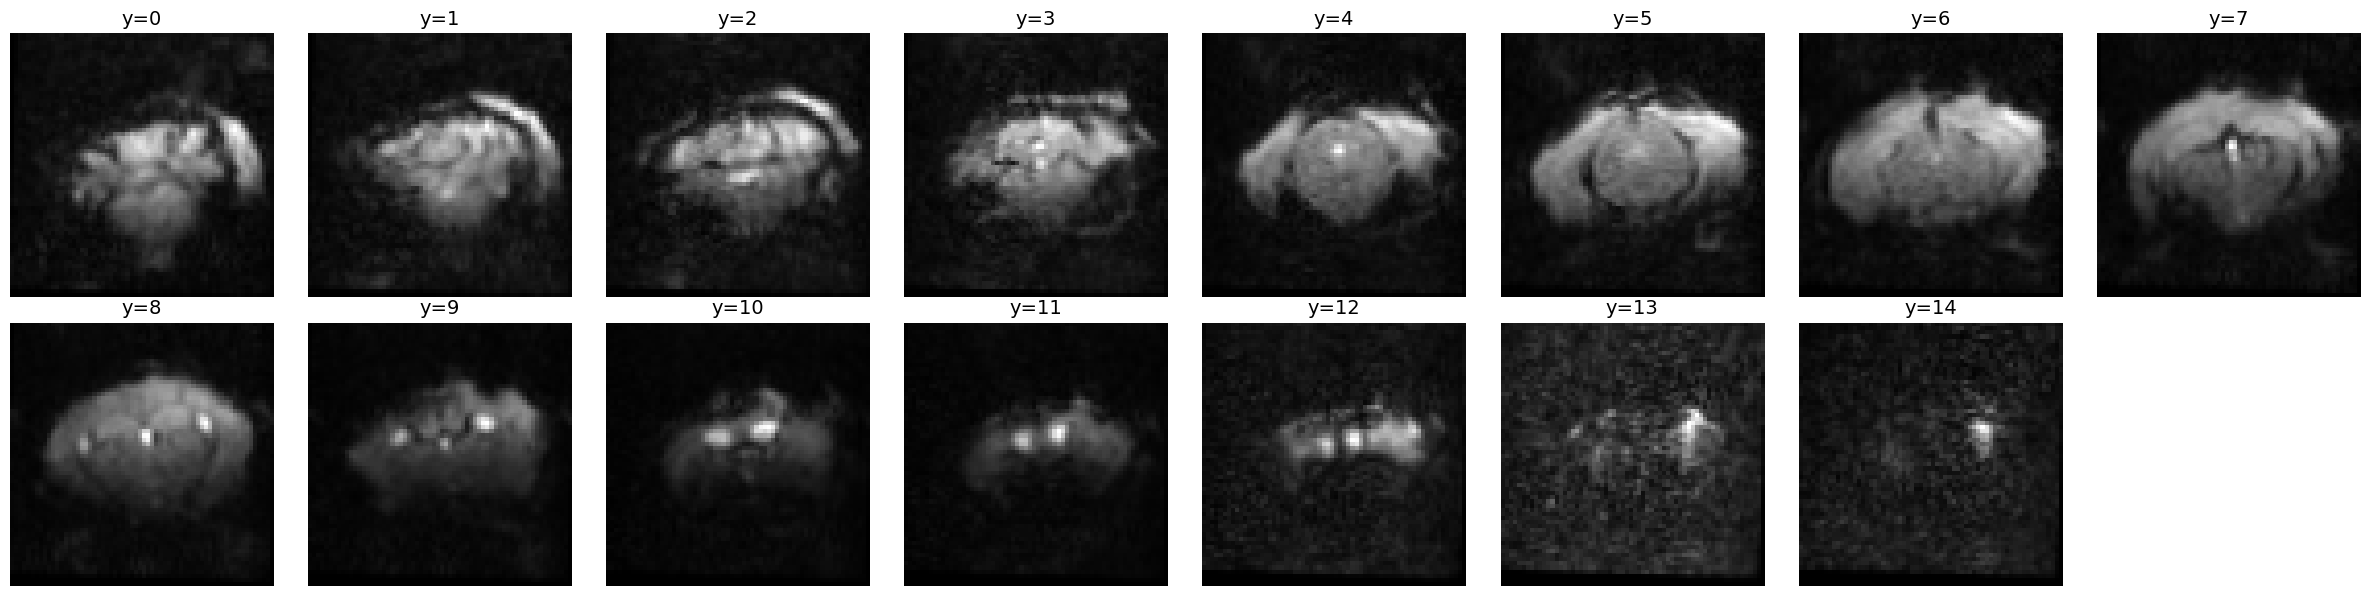

[INFO] Creating motion plots…


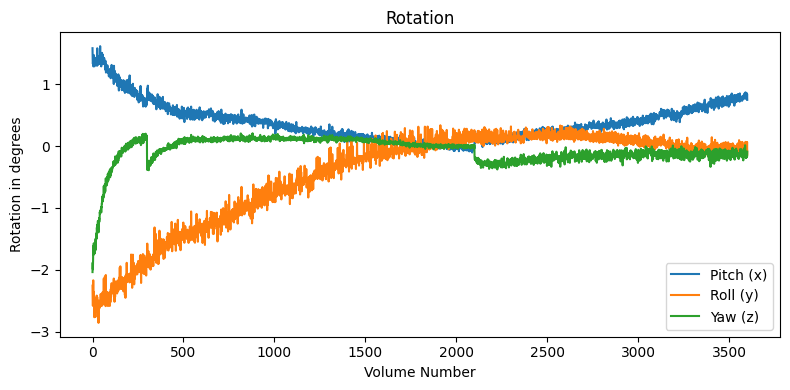

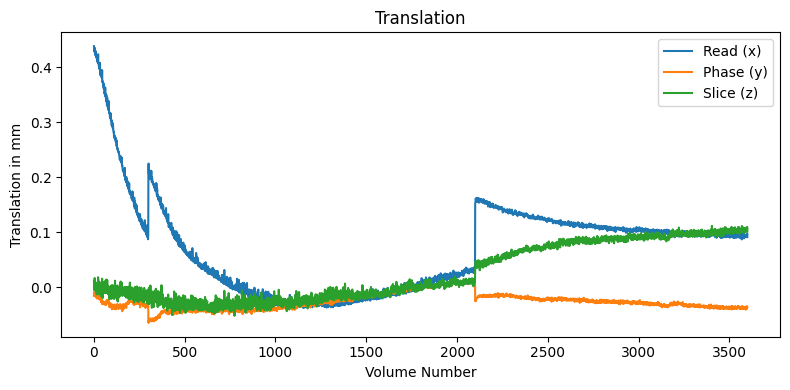

In [8]:
motion_input = "func_norm.nii.gz" if normalise_enabled else "func.nii.gz"

if is_step_enabled("motion_correction"):
    print_header("Applying Motion Correction on raw functional data and plotting motion parameters", bcolors.HEADER)

    if os.path.exists("mc_func.nii.gz"):
        print_statement("Motion Corrected functional data exists. Skipping motion correction.", bcolors.OKGREEN)
    else:
        motion_correction("middle_vol.nii.gz", motion_input, output_prefix="mc_func")

    # Display of the motion corrected image and motion parameters
    view_images("mc_func.nii.gz", cmap="gray")
    plot_motion_parameters("motion.1D")
else:
    print_statement("⏭️ Motion Correction not executed", bcolors.NOTIFICATION)

# Mean Motion-Corrected Image

In [9]:
print_statement(f"Analysis folder: {analysis_dir}", bcolors.NOTIFICATION)
analysis_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysis_dir)

mc_func_file = analysed_func_dir / "mc_func.nii.gz"
run_step(["mean_mc_func.nii.gz"], [mc_func_file], mean_image, str(mc_func_file), "mean_mc_func.nii.gz")

Analysis folder: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis
[OK] Mean image saved -> mean_mc_func.nii.gz


'mean_mc_func.nii.gz'

# Converting Structural Data into NIFTI and Processing it

Analysed Data Path: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/9anatomy

**************************************************************************************************************************************
                                             Converting Bruker to NIFTI: Structural Data                                              
**************************************************************************************************************************************



/Users/pschmidt/miniforge3/envs/fmri/lib/python3.11/site-packages/brkraw/lib/loader.py:951: UserWarning: Unexpected version[VisuVersion];8
  warnings.warn('Unexpected version[VisuVersion];{}'.format(version), UserWarning)


NifTi file is generated... [RGRO_260817_0224_SD_1363_3_1-9-1-anatomy-(E9)]
Fixing orientation to LPI
[OK] Bruker → NIFTI workflow completed.
Cleaning the structural image by manually creating mask
Please create a mask for the structural image and save it as mask_struct.nii.gz


Exception ignored while finalizing file <_io.TextIOWrapper name=5 mode='w' encoding='UTF-8'>:
Traceback (most recent call last):
  File "/Users/pschmidt/fsl/lib/python3.14/threading.py", line 1028, in run
    del self._target, self._args, self._kwargs
OSError: [Errno 9] Bad file descriptor


[OK] Masked file saved → cleaned_struct.nii.gz


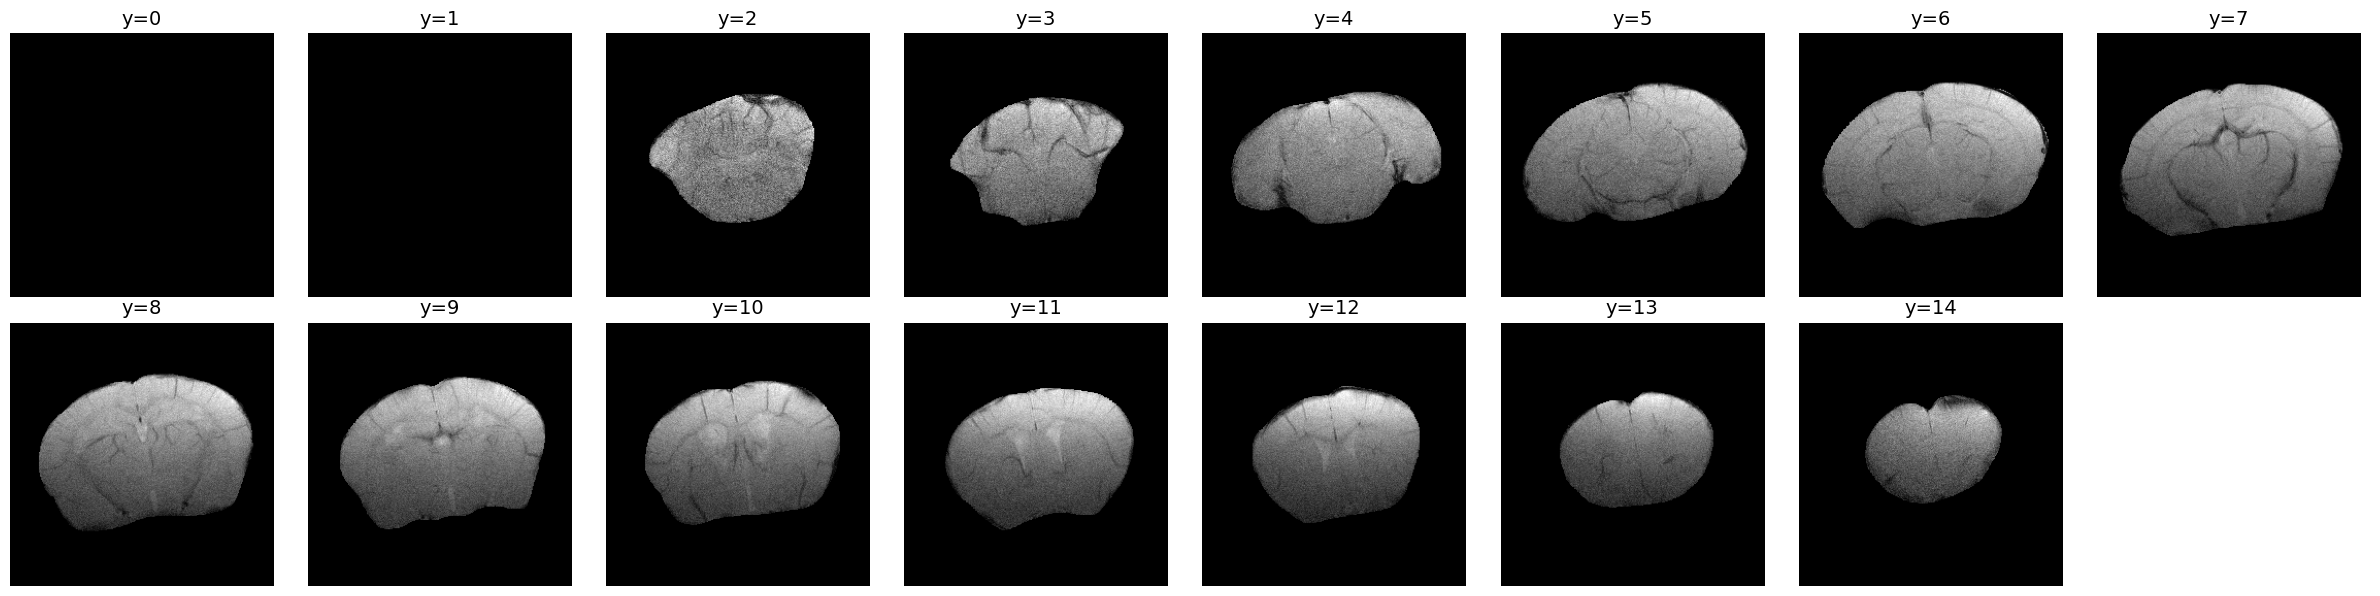

In [10]:
print_statement(f"Analysed Data Path: {analysed_struct_dir}", bcolors.NOTIFICATION)
analysed_struct_dir.mkdir(parents=True, exist_ok=True)
os.chdir(analysed_struct_dir)

if is_step_enabled("bruker_to_nifti"):
    print_header("Converting Bruker to NIFTI: Structural Data", bcolors.HEADER)

    nifti_file = analysed_struct_dir / "struct.nii.gz"
    if nifti_file.exists():
        print_statement("NIfTI file already exists. Skipping conversion.", bcolors.OKGREEN)
    else:
        bruker_to_nifti(in_path, struct_scan_number, "struct.nii.gz")

else:
    print_statement("⏭️ Data Conversion Step not executed, May cause trouble in running further analysis", bcolors.NOTIFICATION)


#Cleaning the structural image by masking it with a manually created mask

if is_step_enabled("masking_file"):
    print_statement("Cleaning the structural image by manually creating mask", bcolors.NOTIFICATION)
    
    if os.path.exists("cleaned_struct.nii.gz"):
        print_statement("Structural Image for Coregistration exists.", bcolors.OKGREEN)
    else:
        print_statement("Please create a mask for the structural image and save it as mask_struct.nii.gz", bcolors.NOTIFICATION)
        subprocess.run(["fsleyes", "struct.nii.gz", os.path.join(analysed_func_dir, "middle_vol.nii.gz")])
        masking_file("struct.nii.gz", "mask_struct.nii.gz", "cleaned_struct.nii.gz")

    structural_file_for_coregistration = os.path.join(analysed_struct_dir, "cleaned_struct.nii.gz")    
    view_images("cleaned_struct.nii.gz", cmap="gray")
    
    #Further shrinking the mask for structural image to get better coregistration results as structural image has high spatial resolution than functional image
    

else:
    print_statement("⏭️ Masks not generated, will not get cleaned data in further pipeline", bcolors.NOTIFICATION)    
    structural_file_for_coregistration = os.path.join(analysed_struct_dir, "struct.nii.gz")    
    view_images("struct.nii.gz", cmap="gray")

In [11]:
# The stimulation analysis only needs the motion corrected data, the mask and the structural image
session_file = save_session(
    analysis_dir,
    in_path=in_path, subject_id=subject_id, func_scan_numbers=func_scan_numbers, struct_scan_number=struct_scan_number,
    analysed_func_dir=analysed_func_dir, analysed_struct_dir=analysed_struct_dir, analysis_dir=analysis_dir,
    mask_file=mask_file, structural_file_for_coregistration=structural_file_for_coregistration, tr=tr,
    drop_vols=drop_vols, scan_normalization=str(analysed_func_dir / "scan_normalization.csv") if normalise_enabled else None,
    distortion_correction=distortion_enabled, rev_pe_scan_number=rev_pe_scan_number or None)
print_statement(f"[OK] Session saved: {session_file}", bcolors.OKGREEN)

[OK] Session saved: /Volumes/pschmidt/fmri_analysis/AnalysedData/MMP9/WT_electric_stim/RGRO_260817_0224_SD_1363_3/stitched_17-20-25_functionalEPI/analysis/session.json
